# Phase 1 — 데이터 탐색(EDA)

이 노트북은 `CLAUDE.md` 11번 섹션의 **Phase 1**을 수행한다.

## 이 노트북에서 확인할 것
1. 그룹별(kpx_group_1/2/3) 발전량의 시간대·월별 패턴, 이용률(설비용량 대비 실제로 발전한 비율) 분포
   - 특히 대회 채점 산식은 **이용률 10% 미만 시간은 아예 채점하지 않으므로**, 이 비율이 얼마나 되는지 먼저 파악한다.
2. SCADA(터빈에 달린 센서가 10분마다 기록한 실측값) 풍속 대 발전량 산점도 → 실제 파워커브(풍속에 따라 출력이 어떻게 변하는지 보여주는 곡선) 확인
3. 기상 예보(LDAPS·GFS) 풍속과 SCADA 실측 풍속을 비교해서, 예보가 실측과 얼마나 잘 맞는지, 어느 격자(예보 지도를 촘촘한 바둑판처럼 나눈 한 칸)·어느 높이가 가장 잘 맞는지 확인
4. 결측·이상치, 특히 "바람은 부는데 출력이 0에 가까운" 터빈 정지/결빙 의심 구간 확인

## 사용하는 데이터
`01_preprocessing.ipynb`에서 이미 만들어 둔 캐시 파일만 읽는다 (원본 CSV를 다시 읽지 않음):
- `data/processed/train_merged.parquet` — 시간당 1행, LDAPS·GFS 예보(격자별) + 그룹별 발전량 라벨
- `data/processed/scada_vestas_hourly.parquet` — VESTAS 12기, 10분 단위 SCADA를 시간당으로 합산한 것 (호기별 발전량·평균 풍속·평균 풍향)
- `data/processed/scada_unison_hourly.parquet` — UNISON 5기, 동일 방식

결과 그림은 `reports/figures/`에 저장하고, 각 단계의 판단과 결과는 `reports/phase1_eda.md`에 정리한다 (CLAUDE.md 9번 문서화 규칙).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 한글이 그래프에서 네모(□)로 깨지지 않도록 폰트를 맑은 고딕으로 지정한다.
# 맑은 고딕은 Windows에 기본 내장된 한글 폰트라 별도 설치가 필요 없다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 위 폰트는 마이너스(-) 기호가 깨져 보이는 경우가 있어 별도 처리

# 경로는 하드코딩하지 않고 상수로 모아둔다 (CLAUDE.md 2번 규칙)
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
# 그룹별 설비용량(1시간 기준 kWh) — 대회 산식(src/metric.py)과 동일한 값
CAPACITY_KWH = {"kpx_group_1": 21600, "kpx_group_2": 21600, "kpx_group_3": 21000}
# 대회 채점 규칙: 이용률(발전량/설비용량)이 이 값보다 낮은 시간대는 채점 대상에서 제외된다
UTILIZATION_THRESHOLD = 0.10

print("설정 완료")


설정 완료


## 1. 전처리 캐시 로드

`01_preprocessing.ipynb`가 만들어 둔 parquet(표를 압축해서 저장하는 파일 형식, csv보다 빠르게 읽힘) 3개를 읽는다.
- `train_merged`: 시간(행) × [예보 변수 + 그룹별 발전량] (열)
- `scada_vestas_hourly` / `scada_unison_hourly`: 시간(행) × 호기별 [발전량, 평균 풍속, 평균 풍향] (열)

세 표 모두 "그 시각에 끝나는 1시간"을 기준으로 만들어졌으므로(CLAUDE.md 2번 규칙), 시각 컬럼으로 그대로 조인해서 비교할 수 있다.


In [2]:
train = pd.read_parquet(PROCESSED_DIR / "train_merged.parquet")
scada_vestas = pd.read_parquet(PROCESSED_DIR / "scada_vestas_hourly.parquet")
scada_unison = pd.read_parquet(PROCESSED_DIR / "scada_unison_hourly.parquet")

print("train_merged:", train.shape)
print("scada_vestas_hourly:", scada_vestas.shape)
print("scada_unison_hourly:", scada_unison.shape)
print()
print("train 기간:", train["forecast_kst_dtm"].min(), "~", train["forecast_kst_dtm"].max())
print("scada_vestas 기간:", scada_vestas["kst_dtm"].min(), "~", scada_vestas["kst_dtm"].max())
print("scada_unison 기간:", scada_unison["kst_dtm"].min(), "~", scada_unison["kst_dtm"].max())


train_merged: (26304, 800)
scada_vestas_hourly: (26304, 38)
scada_unison_hourly: (17544, 17)

train 기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
scada_vestas 기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
scada_unison 기간: 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00


## 2. 그룹별 발전량 기본 통계 · 결측 확인

먼저 세 그룹의 발전량(kWh)이 대략 어떤 범위에 있는지, 결측(빈 값)이 얼마나 있는지 확인한다.
Phase 0에서 이미 `kpx_group_3`의 2022년 전체가 결측이라는 것을 확인했으므로(라벨 자체가 2023년부터 존재), 여기서는 그 사실이 실제로도 그대로인지와 나머지 산발적 결측을 다시 짚고 간다.


In [3]:
desc = train[TARGET_COLS].describe().T
desc["설비용량_kWh"] = [CAPACITY_KWH[c] for c in TARGET_COLS]
desc["결측_개수"] = train[TARGET_COLS].isna().sum().values
desc["결측_비율(%)"] = (train[TARGET_COLS].isna().mean().values * 100).round(2)
desc


,count,mean,std,min,25%,50%,75%,max,설비용량_kWh,결측_개수,결측_비율(%)
kpx_group_1,26200.0,6621.981125,6582.443128,0.0,549.600,4252.168,12206.905,21275.305,21600,104,0.40
kpx_group_2,26201.0,7076.842859,7001.146068,0.0,549.600,4382.337,13508.589,21362.084,21600,103,0.39
kpx_group_3,17538.0,5563.819649,6294.582901,0.0,159.095,2719.074,9979.579,21130.674,21000,8766,33.33


## 3. 이용률(capacity factor) 분포 — 왜 중요한가

**이용률**은 "설비용량 대비 실제로 발전한 비율"이다. 예를 들어 group_1의 설비용량은 21,600kWh인데 어느 시간에 실제로 5,400kWh를 발전했다면 이용률은 25%다.

대회 산식(`src/metric.py`)은 `이용률 < 10%`인 시간대를 **채점에서 완전히 제외**한다. 즉:
- 바람이 거의 안 불어서 발전량이 아주 적은 시간(이용률 10% 미만)은 예측을 얼마나 틀려도 점수에 영향이 없다.
- 반대로 이용률이 높은 시간(바람이 많이 불어 발전량이 큰 시간)을 잘 맞히는 게 점수에 훨씬 중요하다.

따라서 **"이용률 10% 이상인 시간이 전체의 몇 %인가"** 를 먼저 알아야, 앞으로 모델이 정말 집중해야 할 구간의 크기를 가늠할 수 있다.


In [4]:
# 그룹별 이용률 = 발전량(kWh) / 설비용량(kWh). 결측인 시간은 이용률도 결측으로 남긴다.
util = pd.DataFrame({c: train[c] / CAPACITY_KWH[c] for c in TARGET_COLS})

# "이용률 10% 이상" 비율: 결측을 뺀(=라벨이 존재하는) 시간 중에서 계산해야
# kpx_group_3처럼 2022년 라벨이 통째로 없는 그룹이 비율을 왜곡하지 않는다.
rows = []
for c in TARGET_COLS:
    valid = util[c].dropna()
    ratio_over_10pct = (valid >= UTILIZATION_THRESHOLD).mean() * 100
    rows.append({
        "그룹": c,
        "라벨_존재_시간수": len(valid),
        "이용률10%이상_시간수": int((valid >= UTILIZATION_THRESHOLD).sum()),
        "이용률10%이상_비율(%)": round(ratio_over_10pct, 2),
        "평균_이용률(%)": round(valid.mean() * 100, 2),
    })
util_summary = pd.DataFrame(rows)
util_summary


,그룹,라벨_존재_시간수,이용률10%이상_시간수,이용률10%이상_비율(%),평균_이용률(%)
0,kpx_group_1,26200,15915,60.74,30.66
1,kpx_group_2,26201,15891,60.65,32.76
2,kpx_group_3,17538,9414,53.68,26.49


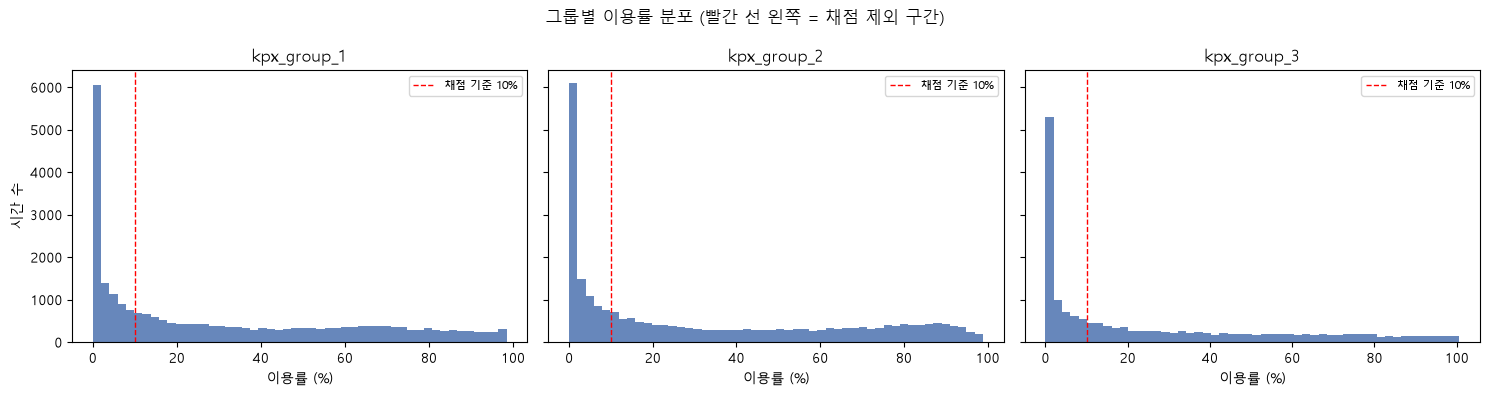

In [5]:
# 이용률 히스토그램 — 그룹별로 분포 모양이 다른지 눈으로 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, c in zip(axes, TARGET_COLS):
    valid = util[c].dropna() * 100  # %로 표시
    ax.hist(valid, bins=50, color="#4C72B0", alpha=0.85)
    ax.axvline(UTILIZATION_THRESHOLD * 100, color="red", linestyle="--", linewidth=1,
               label=f"채점 기준 {UTILIZATION_THRESHOLD*100:.0f}%")
    ax.set_title(c)
    ax.set_xlabel("이용률 (%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("시간 수")
fig.suptitle("그룹별 이용률 분포 (빨간 선 왼쪽 = 채점 제외 구간)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_utilization_hist.png", dpi=120)
plt.show()


## 4. 시간대별·월별 발전 패턴

산악 지형의 바람은 낮/밤, 계절에 따라 패턴이 다른 경우가 많다(예: 낮에는 산비탈을 타고 올라가는 바람, 겨울에는 강한 계절풍). 그룹별로 하루 24시간, 12개월 각각의 평균 이용률을 그려서 패턴이 있는지 확인한다.


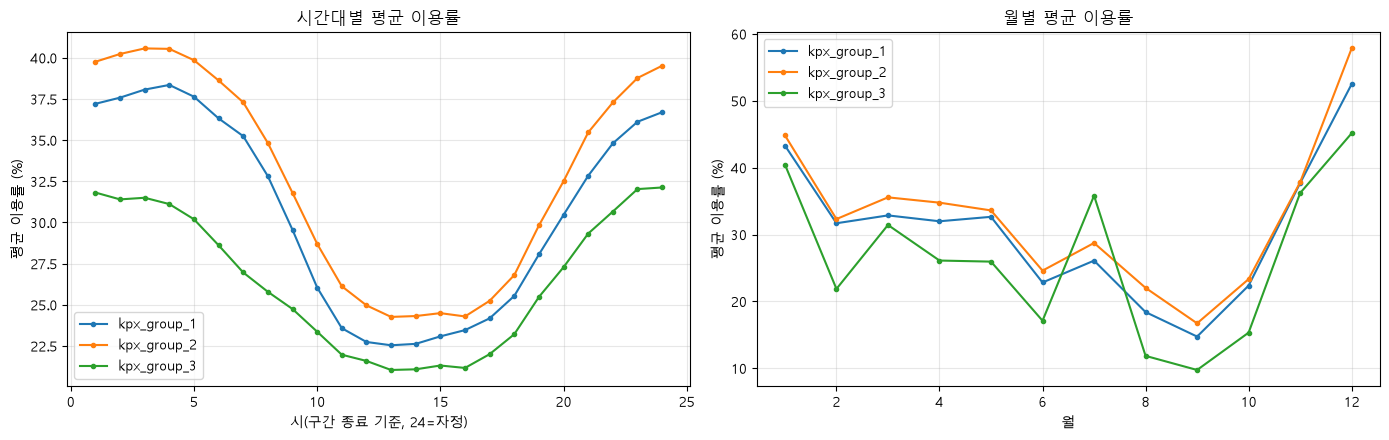

In [6]:
# forecast_kst_dtm은 "그 시각에 끝나는 1시간"을 의미한다(CLAUDE.md 2번 규칙).
# 예: 01:00 값 = 00:00~01:00 발전량. 시간대 패턴을 볼 때는 이 정의를 그대로 유지해
# "hour=1"을 "자정~새벽1시" 구간으로 해석한다.
time_df = train[["forecast_kst_dtm"] + TARGET_COLS].copy()
time_df["hour"] = time_df["forecast_kst_dtm"].dt.hour.replace(0, 24)  # 0시=전날 23~24시 구간이므로 24로 표기 통일
time_df["month"] = time_df["forecast_kst_dtm"].dt.month

hourly_util = pd.DataFrame({c: time_df.groupby("hour")[c].mean() / CAPACITY_KWH[c] * 100 for c in TARGET_COLS})
monthly_util = pd.DataFrame({c: time_df.groupby("month")[c].mean() / CAPACITY_KWH[c] * 100 for c in TARGET_COLS})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
hourly_util.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("시간대별 평균 이용률")
axes[0].set_xlabel("시(구간 종료 기준, 24=자정)")
axes[0].set_ylabel("평균 이용률 (%)")
axes[0].grid(alpha=0.3)

monthly_util.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("월별 평균 이용률")
axes[1].set_xlabel("월")
axes[1].set_ylabel("평균 이용률 (%)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_hourly_monthly_utilization.png", dpi=120)
plt.show()


## 5. SCADA 실측 파워커브 (풍속 → 출력)

**파워커브**란 "풍속이 몇 m/s일 때 터빈이 얼마나 출력을 내는지"를 나타내는 곡선이다. 일반적으로 풍력 터빈은:
- **cut-in(약 3m/s)** 미만: 바람이 너무 약해 출력 0
- cut-in ~ **rated(약 12m/s)**: 풍속이 오르면 출력이 급격히(대략 풍속의 세제곱 비율로) 증가
- rated ~ **cut-out(약 25m/s)**: 이미 최대 출력에 도달해 풍속이 더 올라도 출력은 정격에서 유지(고평지)
- cut-out 이상: 터빈 보호를 위해 블레이드를 세워 출력 강제로 0

호기별 SCADA 풍속(`*_ws_mean`)과 발전량(`*_power_kwh`)을 산점도로 그려서 실제로 이 모양이 나오는지 확인한다. VESTAS는 wtg01~06이 group_1, wtg07~12가 group_2, UNISON wtg01~05가 group_3에 대응한다(`info.xlsx` KPX그룹 컬럼 기준).


In [7]:
# 호기 번호 -> KPX 그룹 매핑 (info.xlsx 기준)
GROUP_TURBINES = {
    "kpx_group_1": [("vestas", f"wtg{i:02d}") for i in range(1, 7)],
    "kpx_group_2": [("vestas", f"wtg{i:02d}") for i in range(7, 13)],
    "kpx_group_3": [("unison", f"wtg{i:02d}") for i in range(1, 6)],
}
SCADA_TABLES = {"vestas": scada_vestas, "unison": scada_unison}
# 단일 터빈 정격출력(kWh, 1시간 기준) — group_1/2는 3.6MW=3600kWh, group_3은 4.2MW=4200kWh
RATED = {"kpx_group_1": 3600, "kpx_group_2": 3600, "kpx_group_3": 4200}

# 파워커브를 그리기 전에 SCADA 발전량 값 자체에 이상치가 있는지 먼저 점검한다.
# (그리고 나서 알게 된 사실: 아래 마크다운 셀 참고 — 정상 범위를 벗어난 값이 실제로 존재했다)
for group in TARGET_COLS:
    for maker, wtg in GROUP_TURBINES[group]:
        tbl = SCADA_TABLES[maker]
        power = tbl[f"{maker}_{wtg}_power_kwh"]
        # 터빈 1기가 정격의 105%를 넘거나 크게 음수가 되는 것은 물리적으로 말이 안 된다.
        # (터빈이 멈춰 있을 때 자체 소비로 수십 kWh 수준의 작은 음수는 정상이다)
        n_extreme = (power.abs() > RATED[group] * 1.05).sum()
        if n_extreme > 0:
            print(f"{maker}_{wtg}: 정격 105% 초과/큰 음수 이상치 {n_extreme}개 "
                  f"(min={power.min():.0f}, max={power.max():.0f})")


vestas_wtg01: 정격 105% 초과/큰 음수 이상치 46개 (min=-42512953, max=42512948)
vestas_wtg02: 정격 105% 초과/큰 음수 이상치 42개 (min=-41959817, max=41959892)
vestas_wtg03: 정격 105% 초과/큰 음수 이상치 44개 (min=-44924519, max=44924514)
vestas_wtg04: 정격 105% 초과/큰 음수 이상치 32개 (min=-39351207, max=39351720)
vestas_wtg05: 정격 105% 초과/큰 음수 이상치 38개 (min=-33717777, max=33717949)
vestas_wtg06: 정격 105% 초과/큰 음수 이상치 30개 (min=-34184409, max=34184717)
vestas_wtg07: 정격 105% 초과/큰 음수 이상치 30개 (min=-29025560, max=29025597)
vestas_wtg08: 정격 105% 초과/큰 음수 이상치 44개 (min=-41143480, max=41146304)
vestas_wtg09: 정격 105% 초과/큰 음수 이상치 32개 (min=-43296239, max=43296220)
vestas_wtg10: 정격 105% 초과/큰 음수 이상치 36개 (min=-51376454, max=51376449)
vestas_wtg11: 정격 105% 초과/큰 음수 이상치 40개 (min=-48950207, max=48950948)
vestas_wtg12: 정격 105% 초과/큰 음수 이상치 34개 (min=-41447781, max=41447846)


**발견한 이상치**: VESTAS 12개 호기 전부에서 터빈 1기당 30~46개 시간(전체 26,304시간의 약 0.1~0.2%)에 정격출력의 105%를 훨씬 넘는(±3천만~5천만 kWh 수준) 값이 나타났다. 이는 발전량이 아니라 **SCADA 센서·통신 오류로 생긴 순간적인 이상값**으로 판단한다 (터빈 1기가 실제로 낼 수 있는 최대치는 3,600kWh인데 이보다 만 배 가까이 큰 값이라 물리적으로 불가능). UNISON 5개 호기에서는 이런 극단값이 관찰되지 않았다.

**대응**: 이 노트북의 파워커브 그림에서는 위 기준(정격의 105% 초과)을 벗어난 값을 제외하고 그린다. 실제 발전량 라벨(`kpx_group_*`)은 이 이상치의 영향을 받지 않으므로(그룹 라벨은 KPX 계량기 값이지 SCADA 합산이 아님) 학습에는 문제가 없지만, **Phase 2에서 SCADA를 파워커브 학습·보조 피처로 쓸 때는 이 필터를 반드시 적용해야 한다** — 그대로 쓰면 몇 개의 극단값이 회귀식 전체를 왜곡할 수 있다.


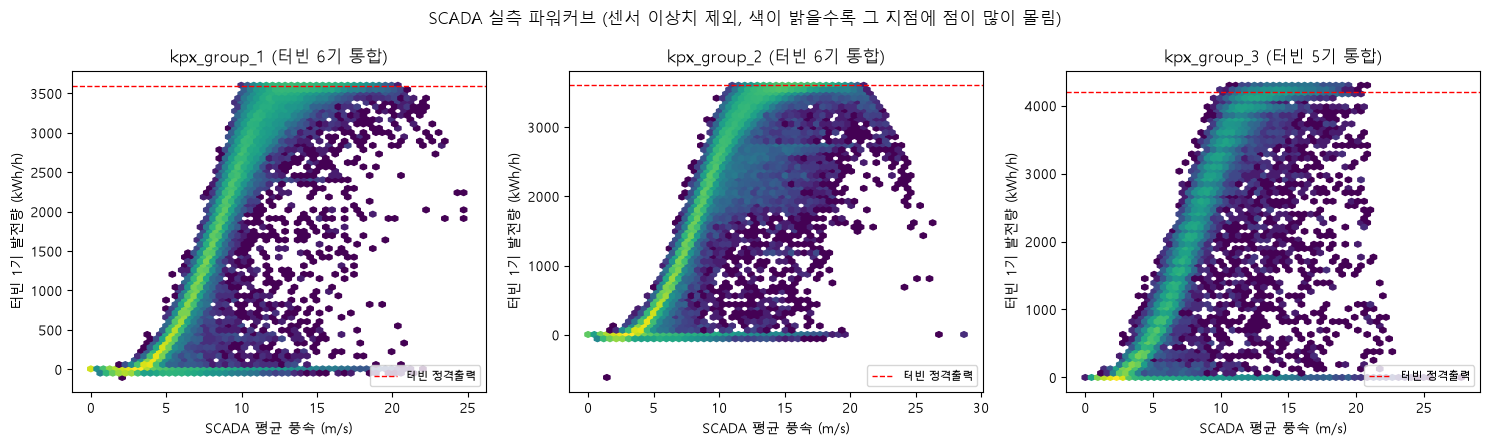

In [8]:
# 이 노트북에서 계속 쓸 그룹별 정격출력(1기 기준) 이름도 남겨둔다 (파워커브 그림의 기준선용)
TURBINE_RATED_KWH = RATED


def collect_turbine_ws_power(group):
    """그룹에 속한 모든 터빈의 (풍속, 발전량) 쌍을 한 표로 모은다.

    입력: group - "kpx_group_1"/"2"/"3" 중 하나
    출력: DataFrame(columns=["ws", "power_kwh"]) — 터빈 수 x 26,304시간(또는 17,544)만큼의 행.
          바로 위 셀에서 확인한 센서 이상치(정격 105% 초과)는 제외한다.
    """
    frames = []
    for maker, wtg in GROUP_TURBINES[group]:
        tbl = SCADA_TABLES[maker]
        frames.append(pd.DataFrame({
            "ws": tbl[f"{maker}_{wtg}_ws_mean"],
            "power_kwh": tbl[f"{maker}_{wtg}_power_kwh"],
        }))
    combined = pd.concat(frames, ignore_index=True).dropna()
    return combined[combined["power_kwh"].abs() <= RATED[group] * 1.05]


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, group in zip(axes, TARGET_COLS):
    pts = collect_turbine_ws_power(group)
    hb = ax.hexbin(pts["ws"], pts["power_kwh"], gridsize=60, cmap="viridis", mincnt=1, bins="log")
    ax.axhline(TURBINE_RATED_KWH[group], color="red", linestyle="--", linewidth=1, label="터빈 정격출력")
    ax.set_title(f"{group} (터빈 {len(GROUP_TURBINES[group])}기 통합)")
    ax.set_xlabel("SCADA 평균 풍속 (m/s)")
    ax.set_ylabel("터빈 1기 발전량 (kWh/h)")
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("SCADA 실측 파워커브 (센서 이상치 제외, 색이 밝을수록 그 지점에 점이 많이 몰림)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_power_curve.png", dpi=120)
plt.show()


## 6. 터빈 정지·결빙 의심 구간 탐지

"바람은 충분히 부는데(cut-in 이상) 출력이 거의 0"인 시간은 바람 탓이 아니라 **터빈이 정비 등으로 멈췄거나, 블레이드에 얼음이 얼어 붙어(결빙) 못 돌린 것**으로 추정할 수 있다(CLAUDE.md 6번 4순위, 13번 결빙 손실 항목).

기준: 풍속 5m/s 이상(확실히 cut-in을 넘긴 구간)인데 발전량이 정격의 5% 미만인 시간의 비율을 계산한다. 월별로 나눠 보면 겨울에 집중되는지(→ 결빙 가능성) 확인할 수 있다.


In [9]:
STOP_WS_THRESHOLD = 5.0  # m/s, cut-in(약 3m/s)을 확실히 넘긴 값
STOP_POWER_RATIO = 0.05  # 정격 대비 5% 미만이면 "거의 안 돌았다"로 간주


def turbine_stop_table(group):
    """터빈별 '풍속 충분한데 출력 거의 없음' 시간 비율과, 그 시간들의 월별 분포를 만든다."""
    rows = []
    monthly_counts = pd.Series(0, index=range(1, 13))
    for maker, wtg in GROUP_TURBINES[group]:
        tbl = SCADA_TABLES[maker]
        ws = tbl[f"{maker}_{wtg}_ws_mean"]
        power = tbl[f"{maker}_{wtg}_power_kwh"]
        stopped = (ws >= STOP_WS_THRESHOLD) & (power < TURBINE_RATED_KWH[group] * STOP_POWER_RATIO)
        valid = ws.notna() & power.notna()
        rows.append({
            "터빈": f"{maker}_{wtg}",
            "유효_시간수": int(valid.sum()),
            "정지의심_시간수": int(stopped.sum()),
            "정지의심_비율(%)": round(stopped.sum() / valid.sum() * 100, 2),
        })
        monthly_counts = monthly_counts.add(
            tbl.loc[stopped, "kst_dtm"].dt.month.value_counts(), fill_value=0
        )
    return pd.DataFrame(rows), monthly_counts.sort_index()


stop_tables = {g: turbine_stop_table(g) for g in TARGET_COLS}
for g in TARGET_COLS:
    print(f"--- {g} ---")
    display(stop_tables[g][0])


--- kpx_group_1 ---


,터빈,유효_시간수,정지의심_시간수,정지의심_비율(%)
0,vestas_wtg01,26304,1306,4.97
1,vestas_wtg02,26304,687,2.61
2,vestas_wtg03,26304,704,2.68
3,vestas_wtg04,26304,1403,5.33
4,vestas_wtg05,26304,1350,5.13
5,vestas_wtg06,26304,1027,3.90


--- kpx_group_2 ---


,터빈,유효_시간수,정지의심_시간수,정지의심_비율(%)
0,vestas_wtg07,26304,992,3.77
1,vestas_wtg08,26304,826,3.14
2,vestas_wtg09,26304,974,3.70
3,vestas_wtg10,26304,898,3.41
4,vestas_wtg11,26304,1101,4.19
5,vestas_wtg12,26304,1026,3.90


--- kpx_group_3 ---


,터빈,유효_시간수,정지의심_시간수,정지의심_비율(%)
0,unison_wtg01,17313,1032,5.96
1,unison_wtg02,17339,544,3.14
2,unison_wtg03,17487,482,2.76
3,unison_wtg04,17506,671,3.83
4,unison_wtg05,17341,656,3.78


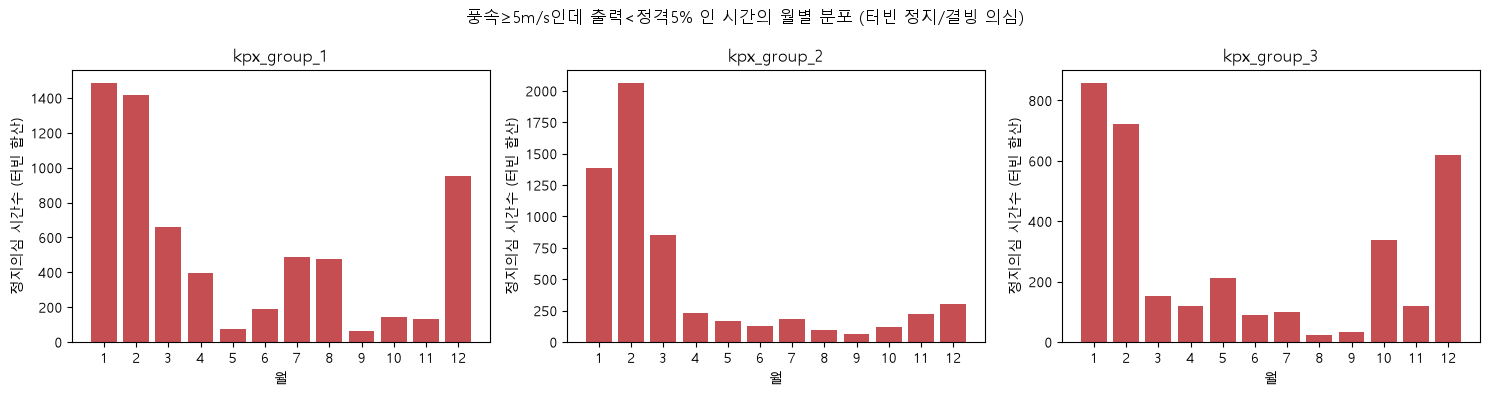

In [10]:
# 정지의심 시간이 겨울(결빙 가능 시기)에 몰리는지 월별로 그려서 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, group in zip(axes, TARGET_COLS):
    _, monthly = stop_tables[group]
    ax.bar(monthly.index, monthly.values, color="#C44E52")
    ax.set_title(group)
    ax.set_xlabel("월")
    ax.set_ylabel("정지의심 시간수 (터빈 합산)")
    ax.set_xticks(range(1, 13))
fig.suptitle("풍속≥5m/s인데 출력<정격5% 인 시간의 월별 분포 (터빈 정지/결빙 의심)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_stop_suspect_monthly.png", dpi=120)
plt.show()


## 7. 격자 좌표 확인 · 터빈에서 가장 가까운 격자 찾기

기상 예보는 **격자(grid)** 라는 바둑판 칸 단위로 제공된다. LDAPS는 16개 격자(약 1.5km 간격, 촘촘함), GFS는 9개 격자(약 0.25도≈27km 간격, 성김)다.

`01_preprocessing.ipynb`에서 격자를 컬럼으로 펼칠 때(pivot) 위경도 컬럼은 빼고 격자 번호만 남겼으므로, 여기서 원본 CSV의 `grid_id, latitude, longitude`만 다시 읽어(용량이 작아 가볍다) **터빈 위치에서 가장 가까운 격자가 몇 번인지** 계산한다. 이 결과는 Phase 2 피처 엔지니어링에서 "어느 격자를 대표 격자로 쓸지" 정할 때 그대로 재사용할 수 있다.

터빈 좌표는 `info.xlsx`에 `도°분'초"N/E` 형식의 문자열로 들어있어 십진수(decimal degree)로 변환한 뒤, 그룹별 터빈 좌표의 평균(중심점)과 각 격자 사이의 거리를 [하버사인 공식](https://ko.wikipedia.org/wiki/%ED%95%98%EB%B2%84%EC%82%AC%EC%9D%B8_%EA%B3%B5%EC%8B%9D)(지구를 구로 가정하고 두 위경도 점 사이 거리를 구하는 공식)으로 계산한다.


In [11]:
import re


def dms_to_dd(coord_str):
    """'37°16'55.61"N 128°57'02.10"E' 같은 도分초 문자열을 (위도, 경도) 십진수로 바꾼다.

    입력: coord_str - info.xlsx의 '좌표(Google)' 컬럼 값 (도, 분, 초, 반구 순서)
    출력: (lat, lon) 튜플, 단위는 십진수 도(degree). S/W 반구는 음수로 표시.
    """
    matches = re.findall(r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NSEW])", coord_str)
    parsed = {}
    for deg, minute, sec, hemi in matches:
        dd = float(deg) + float(minute) / 60 + float(sec) / 3600
        if hemi in ("S", "W"):
            dd = -dd
        parsed[hemi] = dd
    lat = parsed.get("N", parsed.get("S"))
    lon = parsed.get("E", parsed.get("W"))
    return lat, lon


def haversine_km(lat1, lon1, lat2, lon2):
    """두 위경도 점 사이의 거리를 구(지구)를 가정해 계산한다 (하버사인 공식). 출력 단위: km."""
    r = 6371.0  # 지구 평균 반지름(km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


# info.xlsx에서 터빈 좌표 + KPX그룹 컬럼을 읽어 십진수로 변환
info = pd.read_excel(DATA_DIR / "info.xlsx", sheet_name="info", header=3)
info.columns = [str(c) for c in info.columns]
coord_col = [c for c in info.columns if "좌표" in c][0]
group_col = [c for c in info.columns if "KPX" in c and "그룹" in c][0]
info["group_id"] = info[group_col].ffill().astype(int)  # KPX그룹 칸이 호기당 1번만 채워져 있어 앞 값으로 채움
info[["lat", "lon"]] = info[coord_col].apply(lambda s: pd.Series(dms_to_dd(s)))

turbine_centroids = info.groupby("group_id")[["lat", "lon"]].mean()
turbine_centroids.index = [f"kpx_group_{i}" for i in turbine_centroids.index]
print("그룹별 터빈 좌표 중심점")
display(turbine_centroids)

# 원본 CSV에서 격자 좌표만 가볍게 다시 읽는다 (grid_id별로 1행씩만 남기면 되므로 usecols로 최소화)
ldaps_grid = (
    pd.read_csv(DATA_DIR / "train" / "ldaps_train.csv", encoding="utf-8-sig",
                usecols=["grid_id", "latitude", "longitude"])
    .drop_duplicates().sort_values("grid_id").reset_index(drop=True)
)
gfs_grid = (
    pd.read_csv(DATA_DIR / "train" / "gfs_train.csv", encoding="utf-8-sig",
                usecols=["grid_id", "latitude", "longitude"])
    .drop_duplicates().sort_values("grid_id").reset_index(drop=True)
)
print("LDAPS 격자 수:", len(ldaps_grid), " / GFS 격자 수:", len(gfs_grid))


그룹별 터빈 좌표 중심점


,lat,lon
kpx_group_1,37.287127,128.952021
kpx_group_2,37.282255,128.965148
kpx_group_3,37.275199,128.971444


LDAPS 격자 수: 16  / GFS 격자 수: 9


In [12]:
# 그룹별 중심점에서 각 격자까지 거리를 계산해 가장 가까운 격자를 찾는다
nearest_rows = []
for group, center in turbine_centroids.iterrows():
    for name, grid in [("LDAPS", ldaps_grid), ("GFS", gfs_grid)]:
        dist = haversine_km(center["lat"], center["lon"], grid["latitude"], grid["longitude"])
        nearest_idx = dist.idxmin()
        nearest_rows.append({
            "그룹": group,
            "예보종류": name,
            "최근접_grid_id": int(grid.loc[nearest_idx, "grid_id"]),
            "거리_km": round(dist.loc[nearest_idx], 3),
        })
nearest_grid_table = pd.DataFrame(nearest_rows)
nearest_grid_table


,그룹,예보종류,최근접_grid_id,거리_km
0,kpx_group_1,LDAPS,5,0.778
1,kpx_group_1,GFS,5,5.922
2,kpx_group_2,LDAPS,6,0.815
3,kpx_group_2,GFS,5,4.730
4,kpx_group_3,LDAPS,12,0.568
5,kpx_group_3,GFS,5,3.773


## 8. 예보 풍속 vs SCADA 실측 풍속 — 어느 격자·고도가 가장 잘 맞는가

허브 높이(117m)에 가까운 예보 풍속일수록 실제 발전량과 관련이 높을 것이라는 게 6번·13번 규칙의 가설이다. 이를 검증하기 위해:

1. 그룹별로 **터빈들의 실측 평균 풍속**(SCADA `ws_mean`을 그룹 내 터빈 평균) 시계열을 만든다.
2. LDAPS·GFS 각각에서 제공하는 여러 높이(10m, 50m, 80m, 100m, 경계층)의 바람 성분(U, V)으로 풍속 `ws=sqrt(u²+v²)`를 계산한다. 이 값은 이미 `train_merged.parquet`(격자별로 펼쳐진 예보 컬럼)에 다 들어있으므로 원본 CSV를 다시 읽을 필요는 없다.
3. **격자(16개 또는 9개) × 높이** 모든 조합에 대해 실측 평균 풍속과의 상관계수(피어슨 r, -1~1 사이 값으로 1에 가까울수록 두 값이 같은 방향으로 움직인다는 뜻)를 계산하고, 그룹별로 상관이 가장 높은 조합을 찾는다.


In [13]:
# 1) 그룹별 SCADA 실측 평균 풍속 시계열 만들기: 그룹에 속한 터빈들의 ws_mean을 평균
group_actual_ws = pd.DataFrame({"forecast_kst_dtm": train["forecast_kst_dtm"]})
for group in TARGET_COLS:
    ws_cols = []
    for maker, wtg in GROUP_TURBINES[group]:
        tbl = SCADA_TABLES[maker]
        ws_cols.append(tbl.set_index("kst_dtm")[f"{maker}_{wtg}_ws_mean"])
    group_ws = pd.concat(ws_cols, axis=1).mean(axis=1)  # 터빈 간 평균 (그룹 대표 풍속)
    group_actual_ws[group] = group_actual_ws["forecast_kst_dtm"].map(group_ws)

group_actual_ws.describe()


,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
count,26304,26304.000000,26304.000000,17536.000000
mean,2023-07-03 00:30:00,6.782880,7.203019,5.848059
min,2022-01-01 01:00:00,0.000000,0.000000,0.570333
25%,2022-10-02 00:45:00,4.147361,4.170236,2.828167
50%,2023-07-03 00:30:00,6.326667,6.440292,5.015000
75%,2024-04-02 00:15:00,9.080556,9.786111,8.075417
max,2025-01-01 00:00:00,22.431528,25.201333,23.766000
std,NaN,3.365441,3.855660,3.605820


In [14]:
# 2) 소스별로 "높이 이름 -> (u접미사, v접미사, 격자 수)" 정의.
#    data_description.md 기준 실제로 제공되는 높이만 사용한다 (LDAPS엔 80/100m가 없음).
LDAPS_HEIGHTS = {
    "10m": ("heightAboveGround_10_10u", "heightAboveGround_10_10v", 16),
    "50m_max": ("heightAboveGround_50_50MUmax", "heightAboveGround_50_50MVmax", 16),
    "50m_min": ("heightAboveGround_50_50MUmin", "heightAboveGround_50_50MVmin", 16),
    "경계층(5m)": ("heightAboveGround_5_XBLWS", "heightAboveGround_5_YBLWS", 16),
}
GFS_HEIGHTS = {
    "10m": ("heightAboveGround_10_10u", "heightAboveGround_10_10v", 9),
    "80m": ("heightAboveGround_80_u", "heightAboveGround_80_v", 9),
    "100m": ("heightAboveGround_100_100u", "heightAboveGround_100_100v", 9),
    "경계층(PBL)": ("planetaryBoundaryLayer_0_u", "planetaryBoundaryLayer_0_v", 9),
}


def best_grid_corr(prefix, heights, actual_ws):
    """소스(prefix)별 모든 (높이, 격자) 조합의 예보 풍속과 실측 풍속의 상관계수를 계산해
    표로 반환한다.

    입력: prefix - "ldaps" 또는 "gfs", heights - 위 높이 정의 dict, actual_ws - 실측 평균 풍속 Series
    출력: DataFrame(columns=["높이", "grid_id", "상관계수"])
    """
    rows = []
    for height, (u_suf, v_suf, n_grid) in heights.items():
        for g in range(1, n_grid + 1):
            u = train.get(f"{prefix}_g{g}_{u_suf}")
            v = train.get(f"{prefix}_g{g}_{v_suf}")
            if u is None or v is None:
                continue
            ws_forecast = np.sqrt(u ** 2 + v ** 2)
            corr = ws_forecast.corr(actual_ws)
            rows.append({"높이": height, "grid_id": g, "상관계수": corr})
    return pd.DataFrame(rows)


best_combo_rows = []
corr_tables = {}  # (그룹, 소스) -> 전체 조합 상관계수 표 (해석/그림에 재사용)
for group in TARGET_COLS:
    actual = group_actual_ws[group]
    for source_name, prefix, heights in [("LDAPS", "ldaps", LDAPS_HEIGHTS), ("GFS", "gfs", GFS_HEIGHTS)]:
        corr_table = best_grid_corr(prefix, heights, actual)
        corr_tables[(group, source_name)] = corr_table
        best_row = corr_table.loc[corr_table["상관계수"].idxmax()]
        best_combo_rows.append({
            "그룹": group, "예보종류": source_name,
            "최고상관_높이": best_row["높이"], "최고상관_grid_id": int(best_row["grid_id"]),
            "상관계수": round(best_row["상관계수"], 4),
        })

best_combo_table = pd.DataFrame(best_combo_rows)
best_combo_table


,그룹,예보종류,최고상관_높이,최고상관_grid_id,상관계수
0,kpx_group_1,LDAPS,50m_max,13,0.8405
1,kpx_group_1,GFS,100m,2,0.7248
2,kpx_group_2,LDAPS,50m_max,13,0.8418
3,kpx_group_2,GFS,100m,2,0.7254
4,kpx_group_3,LDAPS,50m_max,13,0.8517
5,kpx_group_3,GFS,100m,2,0.7450


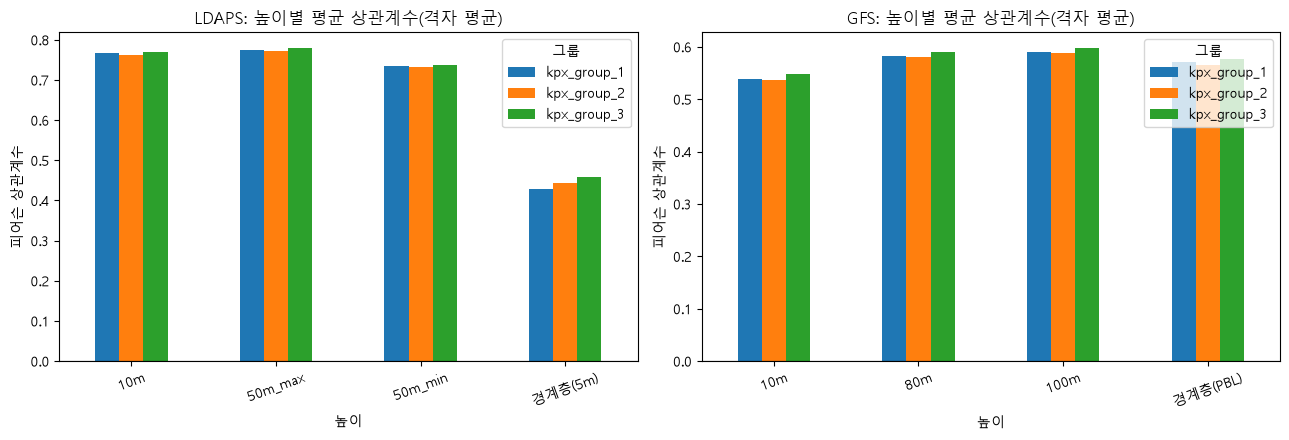

In [15]:
# 높이별 평균 상관계수(격자 평균) — "높이가 올라갈수록 실측과 더 잘 맞는가?" 경향을 본다
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for source_name, ax in zip(["LDAPS", "GFS"], axes):
    plot_df = pd.concat(
        [corr_tables[(g, source_name)].assign(그룹=g) for g in TARGET_COLS], ignore_index=True
    )
    height_order = list((LDAPS_HEIGHTS if source_name == "LDAPS" else GFS_HEIGHTS).keys())
    pivot = plot_df.groupby(["높이", "그룹"])["상관계수"].mean().unstack()[TARGET_COLS].loc[height_order]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{source_name}: 높이별 평균 상관계수(격자 평균)")
    ax.set_ylabel("피어슨 상관계수")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_height_correlation.png", dpi=120)
plt.show()


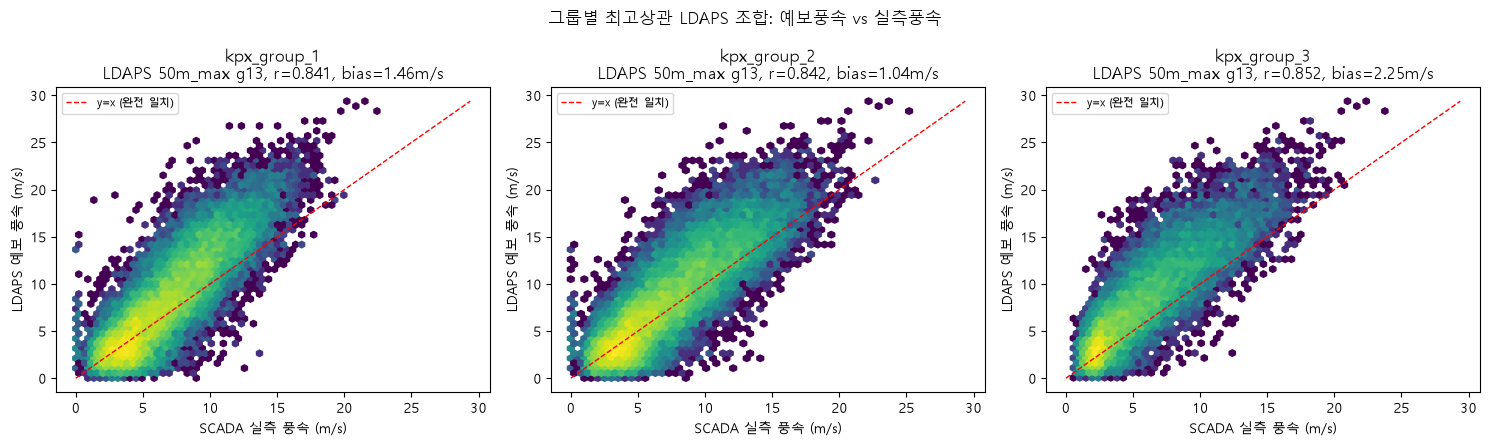

,그룹,예보종류,높이,grid_id,편향(m/s)
0,kpx_group_1,LDAPS,50m_max,13,1.460
1,kpx_group_2,LDAPS,50m_max,13,1.040
2,kpx_group_3,LDAPS,50m_max,13,2.251


In [16]:
# 그룹별 "최고 상관 조합" 예보풍속 vs 실측풍속 산점도 + 편향(bias) 계산
# 편향(bias) = 평균(예보풍속 - 실측풍속). 양수면 예보가 실측보다 과대추정, 음수면 과소추정.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bias_rows = []
for ax, group in zip(axes, TARGET_COLS):
    row = best_combo_table[(best_combo_table["그룹"] == group) & (best_combo_table["예보종류"] == "LDAPS")].iloc[0]
    heights = LDAPS_HEIGHTS
    u_suf, v_suf, _ = heights[row["최고상관_높이"]]
    g = row["최고상관_grid_id"]
    forecast_ws = np.sqrt(train[f"ldaps_g{g}_{u_suf}"] ** 2 + train[f"ldaps_g{g}_{v_suf}"] ** 2)
    actual_ws = group_actual_ws[group]
    valid = forecast_ws.notna() & actual_ws.notna()
    bias = (forecast_ws[valid] - actual_ws[valid]).mean()
    bias_rows.append({"그룹": group, "예보종류": "LDAPS", "높이": row["최고상관_높이"],
                       "grid_id": g, "편향(m/s)": round(bias, 3)})

    ax.hexbin(actual_ws[valid], forecast_ws[valid], gridsize=50, cmap="viridis", mincnt=1, bins="log")
    lim = max(actual_ws[valid].max(), forecast_ws[valid].max())
    ax.plot([0, lim], [0, lim], color="red", linestyle="--", linewidth=1, label="y=x (완전 일치)")
    ax.set_title(f"{group}\nLDAPS {row['최고상관_높이']} g{g}, r={row['상관계수']:.3f}, bias={bias:.2f}m/s")
    ax.set_xlabel("SCADA 실측 풍속 (m/s)")
    ax.set_ylabel("LDAPS 예보 풍속 (m/s)")
    ax.legend(fontsize=8)
fig.suptitle("그룹별 최고상관 LDAPS 조합: 예보풍속 vs 실측풍속")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_ldaps_vs_scada_bestcombo.png", dpi=120)
plt.show()

pd.DataFrame(bias_rows)


## 9. 요약

이 노트북에서 계산한 표·그림은 아래 코드 셀에서 최종적으로 한 번에 모아 출력하고,
같은 내용을 사람이 읽기 좋은 형태로 `reports/phase1_eda.md`에 정리했다.
다음 Phase(Phase 2, `03_features.ipynb`)에서는 여기서 찾은 "그룹별 최고상관 격자·높이"를
피처 우선순위의 출발점으로 쓴다.


In [17]:
print("=== 이용률 요약 ===")
display(util_summary)
print("\n=== 그룹별 최근접 격자 ===")
display(nearest_grid_table)
print("\n=== 그룹별 최고상관 예보-실측 조합 ===")
display(best_combo_table)


=== 이용률 요약 ===


,그룹,라벨_존재_시간수,이용률10%이상_시간수,이용률10%이상_비율(%),평균_이용률(%)
0,kpx_group_1,26200,15915,60.74,30.66
1,kpx_group_2,26201,15891,60.65,32.76
2,kpx_group_3,17538,9414,53.68,26.49



=== 그룹별 최근접 격자 ===


,그룹,예보종류,최근접_grid_id,거리_km
0,kpx_group_1,LDAPS,5,0.778
1,kpx_group_1,GFS,5,5.922
2,kpx_group_2,LDAPS,6,0.815
3,kpx_group_2,GFS,5,4.730
4,kpx_group_3,LDAPS,12,0.568
5,kpx_group_3,GFS,5,3.773



=== 그룹별 최고상관 예보-실측 조합 ===


,그룹,예보종류,최고상관_높이,최고상관_grid_id,상관계수
0,kpx_group_1,LDAPS,50m_max,13,0.8405
1,kpx_group_1,GFS,100m,2,0.7248
2,kpx_group_2,LDAPS,50m_max,13,0.8418
3,kpx_group_2,GFS,100m,2,0.7254
4,kpx_group_3,LDAPS,50m_max,13,0.8517
5,kpx_group_3,GFS,100m,2,0.7450
